# Regression – Task 3: Polynomial Regression Models

**Ziel:** Mindestens zwei polynomielle Regressionsmodelle mit unterschiedlichen Polynomgraden trainieren und evaluieren. Anschliessend Vergleich mit dem linearen Regressionsmodell aus Task 2.

> **Polynomielle Regression:** Erweiterung der linearen Regression – neue Features werden durch Potenzierung erzeugt (x^2, x^3, ...). Das Modell bleibt linear in den Parametern (theta), kann aber **nichtlineare Zusammenhaenge** zwischen Features und Zielgroesse abbilden.

---
### Bibliotheken importieren

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)

---
### Schritt 1: Daten laden und ersten Überblick verschaffen

Wir laden den Datensatz und verschaffen uns einen ersten Überblick über Struktur, Datentypen und fehlende Werte.

In [15]:
# Datensatz einlesen
df = pd.read_csv('../data/dataset_cleaned.csv')

# Unterteile Datensatz in Feature-Set und Zielvariable (target label)
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)  # Alle Spalten außer Churn und CLV_Continuous
y = df['CLV_Continuous']

print('Features (X) – Shape:', X.shape)
print('Zielvariable (y) – Shape:', y.shape)

Features (X) – Shape: (8521, 23)
Zielvariable (y) – Shape: (8521,)


---
### Schritt 2: Polynomial Features erzeugen (Grad 2)

`PolynomialFeatures(degree=2)` erweitert die Feature-Matrix um alle quadratischen Terme und Interaktionsterme. Bei **n** urspruenglichen Features entstehen nach Grad 2 genau **(n+2)·(n+1)/2** Features.

> **Interaktionsterm:** Produkt zweier Features, z.B. `CBalance × CAge` – erfasst kombinierte Effekte.  
> **`include_bias=False`:** Unterdruckt den Bias-Term (Spalte aus Einsen), da `LinearRegression` den Intercept separat berechnet.

In [16]:
# Polynomgrad
DEGREE = 2

# Polynomiale Features erstellen
poly_features = PolynomialFeatures(degree=DEGREE, include_bias=False)
X_poly = poly_features.fit_transform(X)

### Schritt 3: Train/Test-Split

> **Train/Test-Split:** Teilt den Datensatz in 80 % Trainingsdaten und 20 % Testdaten auf. Das Modell lernt **ausschliesslich** auf Trainingsdaten. Testdaten simulieren neue, ungesehene Daten fuer eine ehrliche Evaluation.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

print(f'Trainingsgroesse : {X_train.shape}')
print(f'Testgroesse      : {X_test.shape}')

Trainingsgroesse : (6816, 299)
Testgroesse      : (1705, 299)


Anzahl Features (Grad 2)= [ (n+2) (n+1) / 2 ] -1 = (23+2)(23+1) / 2 = [ (25 * 24) / 2 ] - 1 = 299 Features
Die Zahl "-1" korrigiert den Bias-Term, da `include_bias=False` verwendet wurde. Das Modell bleibt weiterhin linear in den Parametern (β), nur die Eingabe-Features sind nichtlinear.
 

### Schritt 4: Modell trainieren & Trainings + Testdaten evaluieren (Grad 2)

Das Modell wird auf den transformierten Features trainiert. Zuerst evaluieren wir auf den **Trainingsdaten**, um zu sehen, wie gut das Modell die Daten erlernt hat. Anschließend evaluieren wir auf den **Testdaten**, um die Generalisierungsfähigkeit des Modells zu überprüfen.

In [18]:
# Modell trainieren
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train, y_train)

# Vorhersagen auf Trainingsdaten
predictions_train_lin_reg_poly = lin_reg_poly.predict(X_train)

# Evaluation auf Trainingsdaten
print(f'=== Evaluierung Trainingsdaten – Polynomial Regression (Grad {DEGREE}) ===')
print('Mean Absolute Error  (MAE) :', mean_absolute_error(y_train, predictions_train_lin_reg_poly))
print('Mean Squared Error   (MSE) :', mean_squared_error(y_train, predictions_train_lin_reg_poly))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_lin_reg_poly)))
print('R2-Square                  :', r2_score(y_train, predictions_train_lin_reg_poly))

=== Evaluierung Trainingsdaten – Polynomial Regression (Grad 2) ===
Mean Absolute Error  (MAE) : 435.8019829800842
Mean Squared Error   (MSE) : 709004.7349343653
Root Mean Squared Error (RMSE): 842.0241890435009
R2-Square                  : 0.9760920747616075


In [19]:
# Vorhersagen auf Testdaten
predictions_test_lin_reg_poly = lin_reg_poly.predict(X_test)

print('=== Evaluierung Testdaten – Polynomial Regression (Grad 2) ===')
print('Mean Absolute Error  (MAE) :', mean_absolute_error(y_test, predictions_test_lin_reg_poly))
print('Mean Squared Error   (MSE) :', mean_squared_error(y_test, predictions_test_lin_reg_poly))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_lin_reg_poly)))
print('R2-Square                  :', r2_score(y_test, predictions_test_lin_reg_poly))

print('\n--- Zusammenfassung Grad 2 ---')
print(f'Train R2 : {r2_score(y_train, predictions_train_lin_reg_poly):.4f}')
print(f'Test  R2 : {r2_score(y_test, predictions_test_lin_reg_poly):.4f}')
print(f'R2-Gap   : {r2_score(y_train, predictions_train_lin_reg_poly) - r2_score(y_test, predictions_test_lin_reg_poly):.4f}')

=== Evaluierung Testdaten – Polynomial Regression (Grad 2) ===
Mean Absolute Error  (MAE) : 468.61777082975993
Mean Squared Error   (MSE) : 830130.1871945037
Root Mean Squared Error (RMSE): 911.1148046182236
R2-Square                  : 0.9721349472110977

--- Zusammenfassung Grad 2 ---
Train R2 : 0.9761
Test  R2 : 0.9721
R2-Gap   : 0.0040


### Schritt 6: Polynomial Regression – Grad 3

Fuer das zweite polynomielle Modell wird Grad 3 verwendet. Dies erzeugt zusaetzlich kubische Terme (x^3, x^2·y, ...) – die Feature-Anzahl steigt auf **4.494**.

> **Overfitting:** Mit sehr vielen Parametern kann das Modell die Trainingsdaten auswendig lernen, verliert aber die Faehigkeit, auf neuen Daten zu generalisieren.

In [20]:
# Polynomial Features Grad 3 erzeugen
poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3 = poly_features_3.fit_transform(X)
print(f'Original Features : {X.shape[1]}')
print(f'Features Grad 3   : {X_poly_3.shape[1]}')

Original Features : 23
Features Grad 3   : 2599


In [21]:
# Train/Test Split fuer Grad 3
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_poly_3, y, test_size=0.2, random_state=42
)

# Modell trainieren
lin_reg_poly_3 = LinearRegression()
lin_reg_poly_3.fit(X_train_3, y_train_3)

# Vorhersagen auf Trainingsdaten
predictions_train_poly_3 = lin_reg_poly_3.predict(X_train_3)

print('=== Evaluierung Trainingsdaten – Polynomial Regression (Grad 3) ===')
print('Mean Absolute Error  (MAE) :', mean_absolute_error(y_train_3, predictions_train_poly_3))
print('Mean Squared Error   (MSE) :', mean_squared_error(y_train_3, predictions_train_poly_3))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train_3, predictions_train_poly_3)))
print('R2-Square                  :', r2_score(y_train_3, predictions_train_poly_3))

=== Evaluierung Trainingsdaten – Polynomial Regression (Grad 3) ===
Mean Absolute Error  (MAE) : 457.72203638873356
Mean Squared Error   (MSE) : 691289.272095471
Root Mean Squared Error (RMSE): 831.4380747208243
R2-Square                  : 0.9766894473040562


In [22]:
# Vorhersagen auf Testdaten
predictions_test_poly_3 = lin_reg_poly_3.predict(X_test_3)

print('=== Evaluierung Testdaten – Polynomial Regression (Grad 3) ===')
print('Mean Absolute Error  (MAE) :', mean_absolute_error(y_test_3, predictions_test_poly_3))
print('Mean Squared Error   (MSE) :', mean_squared_error(y_test_3, predictions_test_poly_3))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test_3, predictions_test_poly_3)))
print('R2-Square                  :', r2_score(y_test_3, predictions_test_poly_3))

print('\n--- Zusammenfassung Grad 3 ---')
print(f'Train R2 : {r2_score(y_train_3, predictions_train_poly_3):.4f}')
print(f'Test  R2 : {r2_score(y_test_3, predictions_test_poly_3):.4f}')
print(f'R2-Gap   : {r2_score(y_train_3, predictions_train_poly_3) - r2_score(y_test_3, predictions_test_poly_3):.4f}')

=== Evaluierung Testdaten – Polynomial Regression (Grad 3) ===
Mean Absolute Error  (MAE) : 507.7638690118588
Mean Squared Error   (MSE) : 857864.1853601548
Root Mean Squared Error (RMSE): 926.209579609364
R2-Square                  : 0.9712039976626359

--- Zusammenfassung Grad 3 ---
Train R2 : 0.9767
Test  R2 : 0.9712
R2-Gap   : 0.0055


### Schritt 7: Polynomielle Regression: Vergleich

Zuerst die Baseline aus Task 2 (Lineare Regression, Grad 1) neu trainieren, dann alle drei Modelle gegenueberstellen.

In [23]:
# Lineare Regression (Grad 1) als Referenz
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lin_reg = LinearRegression()
lin_reg.fit(X_train_1, y_train_1)
pred_train_1 = lin_reg.predict(X_train_1)
pred_test_1  = lin_reg.predict(X_test_1)

# Vergleichstabelle
comparison = {
    'Modell'           : ['Lineare Regression (Grad 1)',
                          'Polynomial Regression (Grad 2)',
                          'Polynomial Regression (Grad 3)'],
    'Anzahl Features'  : [X.shape[1], X_poly.shape[1], X_poly_3.shape[1]],
    'Train MAE'        : [
        mean_absolute_error(y_train_1, pred_train_1),
        mean_absolute_error(y_train,   predictions_train_lin_reg_poly),
        mean_absolute_error(y_train_3, predictions_train_poly_3)
    ],
    'Test MAE'         : [
        mean_absolute_error(y_test_1, pred_test_1),
        mean_absolute_error(y_test,   predictions_test_lin_reg_poly),
        mean_absolute_error(y_test_3, predictions_test_poly_3)
    ],
    'Train RMSE'       : [
        np.sqrt(mean_squared_error(y_train_1, pred_train_1)),
        np.sqrt(mean_squared_error(y_train,   predictions_train_lin_reg_poly)),
        np.sqrt(mean_squared_error(y_train_3, predictions_train_poly_3))
    ],
    'Test RMSE'        : [
        np.sqrt(mean_squared_error(y_test_1, pred_test_1)),
        np.sqrt(mean_squared_error(y_test,   predictions_test_lin_reg_poly)),
        np.sqrt(mean_squared_error(y_test_3, predictions_test_poly_3))
    ],
    'Train R2'         : [
        r2_score(y_train_1, pred_train_1),
        r2_score(y_train,   predictions_train_lin_reg_poly),
        r2_score(y_train_3, predictions_train_poly_3)
    ],
    'Test R2'          : [
        r2_score(y_test_1, pred_test_1),
        r2_score(y_test,   predictions_test_lin_reg_poly),
        r2_score(y_test_3, predictions_test_poly_3)
    ],
}

df_results = pd.DataFrame(comparison).set_index('Modell')
pd.set_option('display.float_format', '{:.4f}'.format)
df_results

,Anzahl Features,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Modell,,,,,,,
Lineare Regression (Grad 1),23,425.4324,447.1905,878.2192,929.8801,0.9740,0.9710
Polynomial Regression (Grad 2),299,435.8020,468.6178,842.0242,911.1148,0.9761,0.9721
Polynomial Regression (Grad 3),2599,457.7220,507.7639,831.4381,926.2096,0.9767,0.9712


### Schritt 8: Learning Curves (Lernkurven)

Die Lernkurve zeigt, wie sich der Fehler des Modells mit **wachsender Trainingsgroesse** veraendert.

> **Lernkurve:** Modell wird wiederholt auf unterschiedlich grossen Trainingsdatenmengen (1 % bis 100 %) trainiert. Der Fehler auf Trainings- und Validierungsdaten wird gegenueber der Trainingsgroesse aufgetragen.

**Interpretation:**
- Training-RMSE steigt mit mehr Daten (das Modell kann nicht mehr alle Punkte auswendig lernen)
- Validation-RMSE sinkt mit mehr Daten (Generalisierung verbessert sich)
- Grosser Abstand = Overfitting | Beide Kurven hoch = Underfitting

Analog zum Uni-Beispiel (`Time` vs. `Revenue`) wird hier das stark korrelierende Feature **`CBalance`** gegen `CLV_Continuous` als univariates Beispiel verwendet.

**8a – Vergleich der trainierten Modelle (Grad 1, 2, 3):** Zeigt, wie sich der Polynomgrad auf Bias und Varianz auswirkt.  
**8b – Extrembeispiel Grad 10:** Illustriert starkes Overfitting (grosser Gap zwischen Training- und Validation-Kurve).


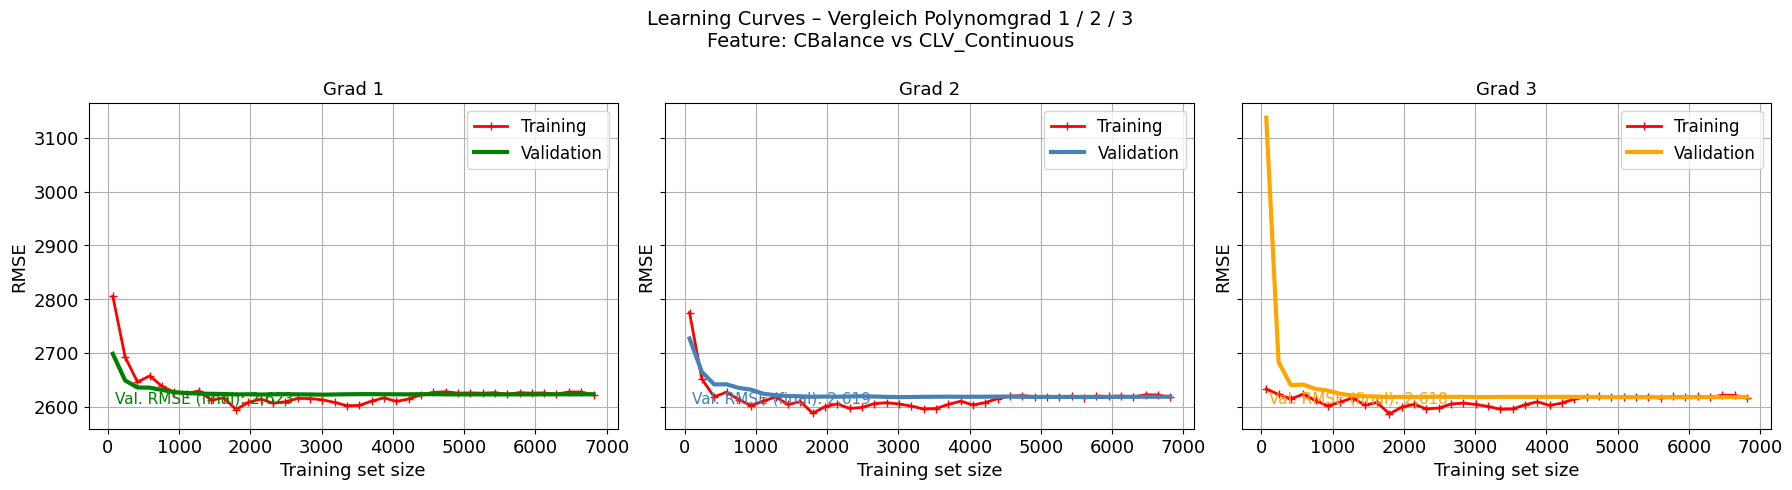

In [24]:
# 8a: Lernkurven-Vergleich – Grad 1, 2, 3
# Univariates Feature: CBalance (staerkste Korrelation mit CLV_Continuous)
X_single = df['CBalance'].values.reshape(-1, 1)
y_lc     = df['CLV_Continuous']

degrees  = [1, 2, 3]
colors   = ['green', 'steelblue', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, degree, color in zip(axes, degrees, colors):
    model_lc = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    train_sizes, train_scores, valid_scores = learning_curve(
        model_lc, X_single, y_lc,
        train_sizes=np.linspace(0.01, 1.0, 40),
        scoring='neg_root_mean_squared_error',
        cv=5
    )
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)

    ax.plot(train_sizes, train_errors, 'r-+', linewidth=2, label='Training')
    ax.plot(train_sizes, valid_errors, linestyle='-', color=color, linewidth=3, label='Validation')
    ax.set_title(f'Grad {degree}')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper right')
    ax.grid()
    ax.annotate(
        f'Val. RMSE (final): {valid_errors[-1]:,.0f}',
        xy=(0.05, 0.08), xycoords='axes fraction', fontsize=11,
        color=color
    )

fig.suptitle('Learning Curves – Vergleich Polynomgrad 1 / 2 / 3\nFeature: CBalance vs CLV_Continuous', fontsize=14)
plt.tight_layout()
plt.show()


#### Interpretation – Vergleich Grad 1 / 2 / 3

| Modell | Erwartetes Verhalten |
|---|---|
| **Grad 1** | Beide Kurven konvergieren auf hohem RMSE-Niveau → **Underfitting** (zu wenig Modellkapazität für 1 Feature) |
| **Grad 2** | Validation-Kurve nähert sich der Training-Kurve an, niedriger RMSE → **gute Balance** |
| **Grad 3** | Kleiner Abstand zwischen Training und Validation, aber ggf. leicht höherer Validation-RMSE → **leichtes Overfitting möglich** |

> Der Gap zwischen Training- und Validation-Kurve ist das zentrale Overfitting-Signal. Schliessen sich beide Kurven auf einem niedrigen Niveau an, generalisiert das Modell gut.


---
#### 8b: Extrembeispiel – Grad 10 (Overfitting-Illustration)

Analog zum Uni-Notebook: Mit Grad 10 und nur einem Feature lernt das Modell die Trainingsdaten nahezu auswendig. Der grosse Gap zwischen Training- und Validation-RMSE macht **Overfitting** deutlich sichtbar.


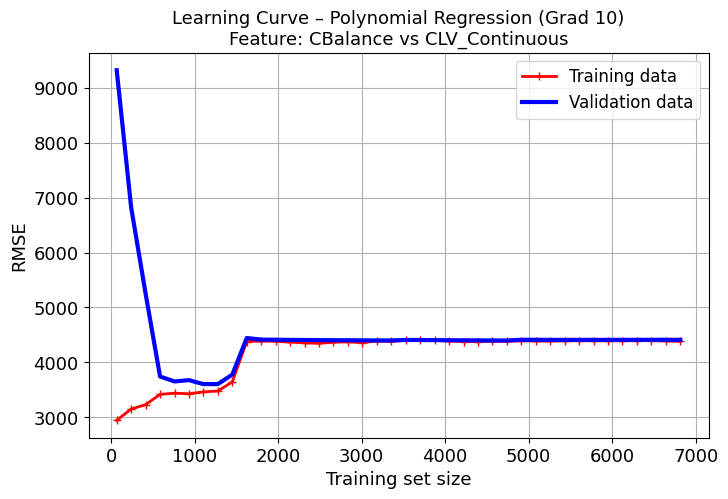

Minimaler Validation-RMSE : 3,601.80
Finaler   Validation-RMSE : 4,409.58
Grosser Gap = Overfitting: Training-RMSE 4,380.73 vs. Validation-RMSE 4,409.58


In [25]:
# 8b: Extrembeispiel – Polynomial Regression Grad 10
polynomial_regression_10 = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression()
)

train_sizes_10, train_scores_10, valid_scores_10 = learning_curve(
    polynomial_regression_10,
    X_single,
    y_lc,
    train_sizes=np.linspace(0.01, 1.0, 40),
    scoring='neg_root_mean_squared_error',
    cv=5
)

train_errors_10 = -train_scores_10.mean(axis=1)
valid_errors_10 = -valid_scores_10.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_10, train_errors_10, 'r-+', linewidth=2, label='Training data')
plt.plot(train_sizes_10, valid_errors_10, 'b-',  linewidth=3, label='Validation data')
plt.legend(loc='upper right')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning Curve – Polynomial Regression (Grad 10)\nFeature: CBalance vs CLV_Continuous')
plt.grid()
plt.show()

print(f'Minimaler Validation-RMSE : {valid_errors_10.min():,.2f}')
print(f'Finaler   Validation-RMSE : {valid_errors_10[-1]:,.2f}')
print(f'Grosser Gap = Overfitting: Training-RMSE {train_errors_10[-1]:,.2f} vs. Validation-RMSE {valid_errors_10[-1]:,.2f}')
